In [1]:
import pandas as pd

df = pd.read_csv("tiktok_data.csv")
df.head()

,date,likes,views,sound
0,2026-07-06 20:00:30 UTC,4908,41700,floating signal - alyzea
1,2026-07-06 01:28:45 UTC,1424,14000,Shadow of the Coffee Bean - Penelope the Perfe...
2,2026-07-04 03:19:57 UTC,32865,377300,som original - surfingoversociety
3,2026-06-07 02:49:06 UTC,3089,26100,original sound - b.ant4
4,2026-05-23 03:53:19 UTC,2052,17000,floating signal - alyzea


In [2]:
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["date"].dt.hour
df["weekday"] = df["date"].dt.dayofweek
df.head()

,date,likes,views,sound,hour,weekday
0,2026-07-06 20:00:30+00:00,4908,41700,floating signal - alyzea,20,0
1,2026-07-06 01:28:45+00:00,1424,14000,Shadow of the Coffee Bean - Penelope the Perfe...,1,0
2,2026-07-04 03:19:57+00:00,32865,377300,som original - surfingoversociety,3,5
3,2026-06-07 02:49:06+00:00,3089,26100,original sound - b.ant4,2,6
4,2026-05-23 03:53:19+00:00,2052,17000,floating signal - alyzea,3,5


In [ ]:

#str.contains checks for "original" in the string, if its there, it will be reported
# as a 0 or 1 (boolean).
# .value_counts() actually does the counting for you.
df["is_original_sound"] = df["sound"].str.contains("original", case=False).astype(int)
df["is_original_sound"].value_counts()


is_original_sound
0    56
1    15
Name: count, dtype: int64

In [ ]:
# very interesting, this "hit" metric checks if a video's view count is above
# my account's median view count.
df["hit"] = (df["views"] > df["views"].median()).astype(int)
df["hit"].value_counts()

hit
0    36
1    35
Name: count, dtype: int64

In [7]:
features = ["hour", "weekday", "is_original_sound"]
# x contains all the variables i know BEFORE posting.. 
X = df[features]

#y is the variable im trying to predict. like will this video be a hit?
y = df["hit"]

X.head()

,hour,weekday,is_original_sound
0,20,0,0
1,1,0,0
2,3,5,1
3,2,6,1
4,3,5,0


In [ ]:
# test size means that im only testing 20% of data size.
# the four outputs are inputs and answers for each group.
#whats prints is the quick rundown on what exactly we're testing here.
# 56 videos, 15 test vids, 3 features to examine here

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(56, 3) (15, 3)


In [18]:
#train the tree
from sklearn.tree import DecisionTreeClassifier

#create decisiontree model, keeping the max depth shallow since we dont have a huge
# sample to work with. 
model = DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [19]:
#how accurate/on point were decision tree's predictions?

from sklearn.metrics import accuracy_score
print("Train accuracy:", accuracy_score(y_train, model.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, model.predict(X_test)))

# from what we observed, since the test/train accuracies weren't too far off..
# and they weren't near 0.5, the time you post ever so slightly influences
# video performance based on the sample we trained the model off of.

Train accuracy: 0.7678571428571429
Test accuracy: 0.6


In [21]:
#which clue was most useful for the prediction model's predictions? scores between
# 0 and 1. lets figure it out chat

# the .feature_importances_ method does the modeling for me.
# its very possible that the model is giving biased preference to the "hour"
# variable because its known that models prefer models with more values to them

# that is, there are 24 hours vs. "yes" vs. "no" for original sounds, 7 weekdays


importances = pd.Series(
    model.feature_importances_, index=features
).sort_values(ascending=False)

importances

hour                 0.574992
is_original_sound    0.322735
weekday              0.102273
dtype: float64

Matplotlib is building the font cache; this may take a moment.


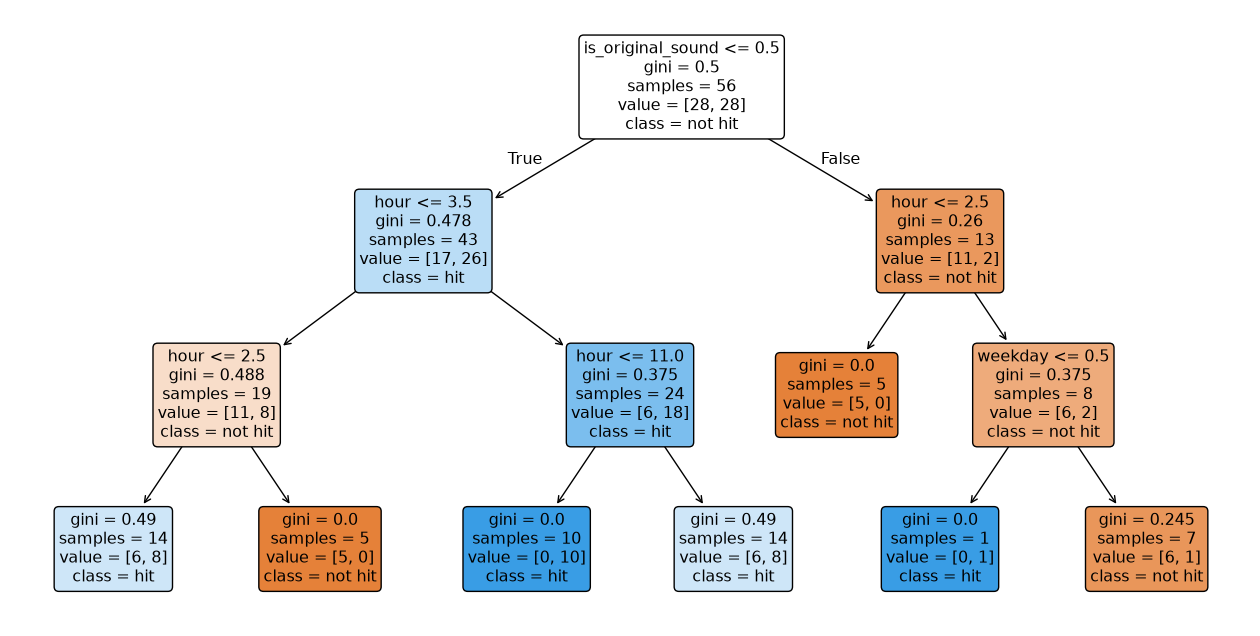

In [ ]:
# now, lets plot the model's observations.

# the top layer of each box is the variable thats being questioned on in order to make the predictions.

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16,8))

#this plot_tree draws my DecisionTree as the yes/no flowchart.
plot_tree(
    model,

    #this gives the boxes real words instead of numbers (booleans)
    feature_names=features,
    class_names=["not hit","hit"],
    filled=True,
    rounded=True,
)
plt.show()

In [23]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 7.6 MB/s  0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 7.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
